# **Transfer Learning y Fine-Tuning**

* Oscar Ivanovich Avila Chiu 35676
* Axel Daniel Nuño Arrieta 35859

In [8]:
import json
import time
from io import BytesIO
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [10]:
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights

weights = VGG16_Weights.DEFAULT
model = vgg16(weights=weights)

pre_trans = weights.transforms()

model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

##**Dataset**
* Daisy : 0
* Gabu : 1
* Otro : 2

In [11]:
# Limpiar antiguos datos
# !rm -rf dataset.zip
# !rm -rf dataset

In [16]:
# Importar zip dataset
!unzip -q dataset.zip

In [17]:
# Limpiar datos que no sirven
# !rm -rf __MACOSX
# !find dataset -name ".DS_Store" -delete

In [18]:
import os

print(os.listdir('dataset'))
print(os.listdir('dataset/train'))

['.DS_Store', 'val', 'train', 'test']
['.DS_Store', 'Otro', 'Daisy', 'Gabu']


In [19]:
# Datasets a variables
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root="dataset/train",
    transform=pre_trans
)

val_dataset = datasets.ImageFolder(
    root="dataset/val",
    transform=pre_trans
)

test_dataset = datasets.ImageFolder(
    root="dataset/test",
    transform=pre_trans
)

print(train_dataset.class_to_idx)
print("Train len:", len(train_dataset))
print("Test len:", len(test_dataset))
print("Val len:", len(val_dataset))

{'Daisy': 0, 'Gabu': 1, 'Otro': 2}
Train len: 144
Test len: 18
Val len: 18


In [20]:
import os

print("=== Particion 80/10/10 === \n")
for root, dirs, files in os.walk("dataset/train"):
    print(root, len(files))

print("")
for root, dirs, files in os.walk("dataset/test"):
    print(root, len(files))
print("")

for root, dirs, files in os.walk("dataset/val"):
    print(root, len(files))

=== Particion 80/10/10 === 

dataset/train 1
dataset/train/Otro 97
dataset/train/Daisy 25
dataset/train/Gabu 25

dataset/test 1
dataset/test/Otro 12
dataset/test/Daisy 3
dataset/test/Gabu 4

dataset/val 1
dataset/val/Otro 12
dataset/val/Daisy 3
dataset/val/Gabu 4


In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

##**Modelos**

###**Modelo 1 -> VGG16 Transfer Learning**

In [22]:
# Cambio ultima capa
num_classes = 3  # Gabu, Daisy, Otro

model.classifier[6] = nn.Linear(
    model.classifier[6].in_features,
    num_classes
)

In [23]:
# Congelar TODO modelo
for param in model.parameters():
    param.requires_grad = False

In [24]:
# Descongelar SOLo ultima capa
for param in model.classifier[6].parameters():
    param.requires_grad = True

In [25]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

features.0.weight False
features.0.bias False
features.2.weight False
features.2.bias False
features.5.weight False
features.5.bias False
features.7.weight False
features.7.bias False
features.10.weight False
features.10.bias False
features.12.weight False
features.12.bias False
features.14.weight False
features.14.bias False
features.17.weight False
features.17.bias False
features.19.weight False
features.19.bias False
features.21.weight False
features.21.bias False
features.24.weight False
features.24.bias False
features.26.weight False
features.26.bias False
features.28.weight False
features.28.bias False
classifier.0.weight False
classifier.0.bias False
classifier.3.weight False
classifier.3.bias False
classifier.6.weight True
classifier.6.bias True


In [26]:
from tqdm import tqdm
import torch

def get_batch_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = torch.sum(preds == labels).item()
    return correct


def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, device):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    _model.to(device)

    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for epoch in iterator:
        _model.train()
        train_loss = 0.0
        train_correct = 0

        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            _optimizer.zero_grad()

            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)

            loss.backward()
            _optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_correct += get_batch_accuracy(outputs, y_batch)

        epoch_train_loss = train_loss / len(_train_loader.dataset)
        epoch_train_acc = train_correct / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_correct = 0

        with torch.no_grad():
            for X_val, y_val in _val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)

                val_outputs = _model(X_val)
                loss = _criterion(val_outputs, y_val)

                val_loss += loss.item() * X_val.size(0)
                val_correct += get_batch_accuracy(val_outputs, y_val)

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        epoch_val_acc = val_correct / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{epoch_val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(epoch_val_acc)

    return res

In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier[6].parameters(),
    lr=1e-3
)

history_vgg_tl = train(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    10,
    device=device
)


Training: 100%|██████████| 10/10 [00:55<00:00,  5.56s/epoch, train_acc=1.0000, train_loss=0.0017, val_acc=1.0000, val_loss=0.0021]


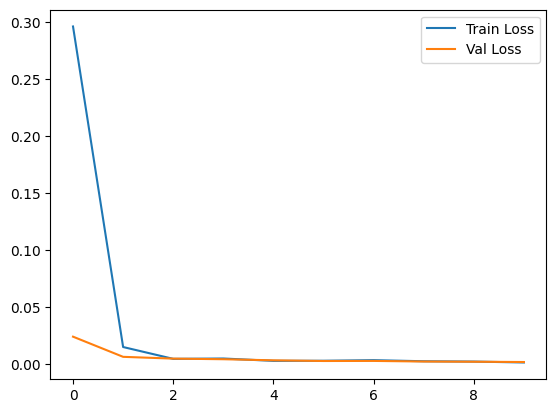

In [28]:
import matplotlib.pyplot as plt

plt.plot(history_vgg_tl['train_loss'], label='Train Loss')
plt.plot(history_vgg_tl['val_loss'], label='Val Loss')
plt.legend()
plt.show()

###**Modelo 2 -> VGG16 Fine-Tuning**

In [29]:
import copy

model_vgg_tl = model  # ya entrenado

model_vgg_ft = copy.deepcopy(model_vgg_tl)

In [30]:
# Congelar TODO y descongelar
for param in model_vgg_ft.parameters():
    param.requires_grad = False

for param in model_vgg_ft.features[24:].parameters():
    param.requires_grad = True

for param in model_vgg_ft.classifier[6].parameters():
    param.requires_grad = True

for name, param in model_vgg_ft.named_parameters():
    print(name, param.requires_grad)

features.0.weight False
features.0.bias False
features.2.weight False
features.2.bias False
features.5.weight False
features.5.bias False
features.7.weight False
features.7.bias False
features.10.weight False
features.10.bias False
features.12.weight False
features.12.bias False
features.14.weight False
features.14.bias False
features.17.weight False
features.17.bias False
features.19.weight False
features.19.bias False
features.21.weight False
features.21.bias False
features.24.weight True
features.24.bias True
features.26.weight True
features.26.bias True
features.28.weight True
features.28.bias True
classifier.0.weight False
classifier.0.bias False
classifier.3.weight False
classifier.3.bias False
classifier.6.weight True
classifier.6.bias True


In [33]:
optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_vgg_ft.parameters()),
    lr=1e-5
)

history_vgg_ft = train(
    model_vgg_ft,
    train_loader,
    val_loader,
    criterion,
    optimizer_ft,
    10,
    device=device
)

Training: 100%|██████████| 10/10 [00:59<00:00,  5.94s/epoch, train_acc=1.0000, train_loss=0.0000, val_acc=1.0000, val_loss=0.0000]


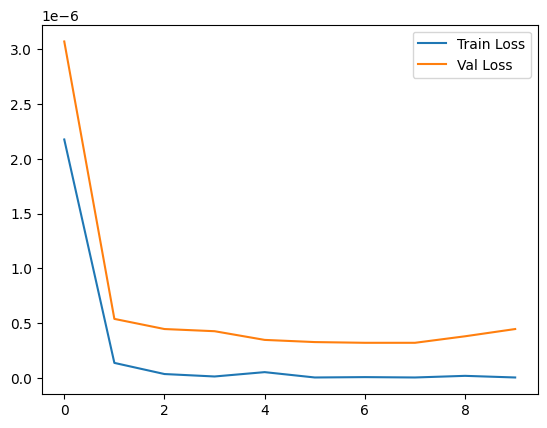

In [34]:
import matplotlib.pyplot as plt

plt.plot(history_vgg_ft['train_loss'], label='Train Loss')
plt.plot(history_vgg_ft['val_loss'], label='Val Loss')
plt.legend()
plt.show()

###**Modelo 3 -> EfficientNet Transfer Learning**

In [40]:
from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights

weights_b0 = EfficientNet_B0_Weights.DEFAULT
model_b0 = efficientnet_b0(weights=weights_b0)

model_b0.to(device)

pre_trans_b0 = weights_b0.transforms()

In [41]:
num_classes = 3

model_b0.classifier[1] = nn.Linear(
    model_b0.classifier[1].in_features,
    num_classes
)

In [42]:
# Congelar y descongelar
for param in model_b0.parameters():
    param.requires_grad = False

for param in model_b0.classifier[1].parameters():
    param.requires_grad = True

for name, param in model_b0.named_parameters():
    print(name, param.requires_grad)

features.0.0.weight False
features.0.1.weight False
features.0.1.bias False
features.1.0.block.0.0.weight False
features.1.0.block.0.1.weight False
features.1.0.block.0.1.bias False
features.1.0.block.1.fc1.weight False
features.1.0.block.1.fc1.bias False
features.1.0.block.1.fc2.weight False
features.1.0.block.1.fc2.bias False
features.1.0.block.2.0.weight False
features.1.0.block.2.1.weight False
features.1.0.block.2.1.bias False
features.2.0.block.0.0.weight False
features.2.0.block.0.1.weight False
features.2.0.block.0.1.bias False
features.2.0.block.1.0.weight False
features.2.0.block.1.1.weight False
features.2.0.block.1.1.bias False
features.2.0.block.2.fc1.weight False
features.2.0.block.2.fc1.bias False
features.2.0.block.2.fc2.weight False
features.2.0.block.2.fc2.bias False
features.2.0.block.3.0.weight False
features.2.0.block.3.1.weight False
features.2.0.block.3.1.bias False
features.2.1.block.0.0.weight False
features.2.1.block.0.1.weight False
features.2.1.block.0.1.bia

In [43]:
criterion = nn.CrossEntropyLoss()

optimizer_b0 = torch.optim.Adam(
    model_b0.classifier[1].parameters(),
    lr=1e-3
)

history_effnet_tl = train(
    model_b0,
    train_loader,
    val_loader,
    criterion,
    optimizer_b0,
    10,
    device=device
)

Training: 100%|██████████| 10/10 [00:46<00:00,  4.64s/epoch, train_acc=0.9792, train_loss=0.1208, val_acc=0.9444, val_loss=0.2572]


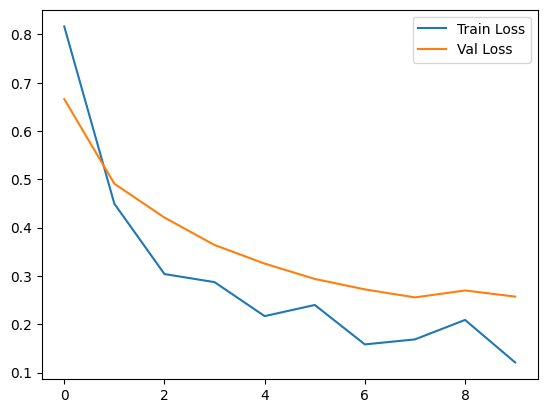

In [44]:
import matplotlib.pyplot as plt

plt.plot(history_effnet_tl['train_loss'], label='Train Loss')
plt.plot(history_effnet_tl['val_loss'], label='Val Loss')
plt.legend()
plt.show()

###**Modelo 4 -> EfficientNet Fine-Tuning**

In [46]:
import copy

model_effnet_tl = model_b0
model_effnet_ft = copy.deepcopy(model_effnet_tl)

##**Evaluación y comparación**

In [ ]:
results = {
    "VGG_TL": history_vgg_tl,
    "VGG_FT": history_vgg_ft,
    "EffNet_TL": history_effnet_tl
    "EffNet_FT": history_effnet_ft
}